In [2]:
import numpy as np
#from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt
import time
from tabulate import tabulate
import pandas as pd

In [3]:

# coeficient of u, u' and u'' , just modify them if you want to slove another equation
#----------------------------------------------------------------------------------------------------------------------------------------
def cft_u(x):return (n**2/(4*alpha**2*S*A(x)))+m(k,n)/(4*S*B(x))

def cft_u1(x):return -A1(x)/S-A(x)*B1(x)/(2*S*B(x))

def cft_u2(x):return -A(x)/S

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#These are part of the coeficients :

v=0.28170155790877400592334265111700731965718026322934836713673192303460348039980182970389127012050565043465821289355805066025672639447355195448802045593143670911913641107077463154220342848408998160904869975888148775790690583653893672393609101177960611295355370425929891516847791327020041738790737066438709875972148984910134433579627631902521061632838103401850319253976008102644621765838676176099271395298953039171688583280447923068135052230749778606605254003317895279533270534639578257130709831686526204

lamda=1 

S=(3*(1+v**2))/lamda
alpha=1/(2*(3+v**2))

def A(x):
    return (3-v**2-v**2*x**2*(1+v**2))*(1-x**2)/(1-v**2*x**2)

def B(x):
    return (1-v**2*x**2)/(3+6*v**2-v**4)

def A1(x):
    return -(2*x*(v**6*x**4+v**4*(x**4-2*x**2+2)-v**2*(2*x**2+3)+3))/((1-v**2*x**2)**2)

def B1(x):
    return 2*v**2*x/(v**4-6*v**2-3)



def L(k,n):
    return 2*k+abs(n)

def m(k,n):
    return L(k,n)*(L(k,n)+2)-n**2

#----------------------------------------------------------------------------------------------------------------------------------------






def u(a,b):
    return np.cos(b*np.pi*a/2)  # u

def u1(a,b):
    return -b*np.pi*np.sin(b*np.pi*a/2)/2  # u'

def u2(a,b):
    return -b**2*np.pi**2*np.cos(b*np.pi*a/2)/4  # u''
def chebyshev(myN):
    sList=np.linspace(0,2,myN+2)[1:-1]  # omit the boundary samples, this gives better convergence
    Phi=np.array([[u(a,b) for a in sList] for b in range(myN)] ) #this is a shortcut method to create the nested list
    
    myL=np.array([[   cft_u1(a-1)  *u1(a,b)+  cft_u2(a-1)*u2(a,b)    +  cft_u(a-1)*u(a,b)  
               for a in sList] for b in range(myN)])
    
    evals,evecs = np.linalg.eig(np.dot(myL,np.linalg.inv(Phi)))
    return [evals,evecs]
    #return myL

In [3]:
n=0
k=0
np.sort(chebyshev(300)[0])[0:8]

array([ 0.        ,  1.86607842,  5.62182544, 11.29232237, 18.89767185,
       28.45520153, 39.97963766, 53.48345652])

In [79]:
%timeit -n 1 -r 1 np.sort(chebyshev(500)[0])[0:8]

9.63 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [80]:
%timeit -n 1 -r 1 np.sort(chebyshev(100)[0])[0:8]

375 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [8]:

nRange=3  #Range of n, the program is solving the problem up to n=nRange
kRange=3  #Range of k, the program is solving the problem up to k=nRange
number_of_evals=8  # The amount of eigenvalues we want to analyze for each group of n,k

N=1000 #The amount of basic functions we use, larger n means better accuracy and longer time
lamda=1/2 # Value of Λ, a coefficient of our equation

'''
The code above can be changed to get result for different cases, while the below are source codes 
'''


sstart = time.time()
tablelist1=[]
head1=["n","k","order:"]+list(range(1,number_of_evals+1))


for n in range (nRange+1):
    for k in range (kRange+1):
        initial=[n,k," "]
        elist=np.sort(chebyshev(N)[0])[0:number_of_evals].tolist()
        tablelist1.append(initial+elist)

        
print(tabulate(tablelist1, headers=head1, tablefmt="grid"))
eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)
    
#Yiqing's(?)    (for N=1000)

+-----+-----+------------------------+----------+----------+----------+---------+---------+---------+----------+----------+
|   n |   k | order of eigenvalue:   |        1 |        2 |        3 |       4 |       5 |       6 |        7 |        8 |
+=====+=====+========================+==========+==========+==========+=========+=========+=========+==========+==========+
|   0 |   0 |                        |  0       |  1.85661 |  5.57544 | 11.1659 | 18.6349 | 27.9891 |  39.2349 |  52.3778 |
+-----+-----+------------------------+----------+----------+----------+---------+---------+---------+----------+----------+
|   0 |   1 |                        |  2.20143 |  4.10662 |  7.81343 | 13.4007 | 20.8686 | 30.2223 |  41.4677 |  54.6103 |
+-----+-----+------------------------+----------+----------+----------+---------+---------+---------+----------+----------+
|   0 |   2 |                        |  6.60122 |  8.6051  | 12.2914  | 17.8713 | 25.3365 | 34.6889 |  45.9335 |  59.0755 |
+-----+-

# Sort the eigenvalues and trace the index


In [9]:

nRange=3  #Range of n, the program is solving the problem up to n=nRange
kRange=3  #Range of k, the program is solving the problem up to k=nRange
number_of_evals=8  # The amount of eigenvalues we want to analyze for each group of n,k

N=1000 #The amount of basic functions we use, larger n means better accuracy and longer time
lamda=1/2 # Value of Λ, a coefficient of our equation

'''
The code above can be changed to get result for different cases, while the below are source codes 
'''



sstart = time.time()
total_evals=[]

tablelist2=[]
tablerow=["Order Of Smallest Eigenvalues"," ","n","k","order"," ","value"]
head2=["Order Of Smallest Eigenvalues"," ","n","k","order"," ","value                     "]

for n in range (nRange+1):
    for k in range (kRange+1):
        elist=np.sort(chebyshev(N)[0])[0:number_of_evals].tolist()
        total_evals.append(elist)
#print(total_evals)            
total_evals=np.array(total_evals)

for i in range(number_of_evals*(nRange+1)*(kRange+1)):
    tablerow[0]=i+1
    min_xy = np.where( total_evals ==  total_evals.min() )
    a=(min_xy[0][0], min_xy[1][0])
    tablerow[2]=a[0]//(kRange+1)
    tablerow[3]=a[0]%(kRange+1)
    tablerow[4]=a[1]+1
    tablerow[6]=total_evals[a[0]][a[1]]
    total_evals[a[0]][a[1]]=9999999999999999999999999999
    #print(tablerow)
    tablelist2.append(tablerow)
    #print(tablelist2)
    tablerow=["Order Of Smallest Eigenvalues"," ","n","k","order"," ","value"]
    #print(total_evals)
    
df_OrderedEvals = pd.DataFrame(tablelist2,columns=head2)
                   
with pd.ExcelWriter('Page_Eigenvalues.xlsx') as writer:                  
    df_OrderedEvals.to_excel(writer,sheet_name="Ordered Eigenvalues")    
print(tabulate(tablelist2, headers=head2, tablefmt="grid"))


eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)
    

+---------------------------------+-----+-----+-----+---------+-----+-----------+
|   Order Of Smallest Eigenvalues |     |   n |   k |   order |     |     value |
+=================================+=====+=====+=====+=========+=====+===========+
|                               1 |     |   0 |   0 |       1 |     |   0       |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               2 |     |   0 |   0 |       2 |     |   1.85661 |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               3 |     |   0 |   1 |       1 |     |   2.20143 |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               4 |     |   1 |   0 |       1 |     |   2.46767 |
+---------------------------------+-----+-----+-----+---------+-----+-----------+
|                               5 |     |   0 |   1 |       2 |     |   4.10662 |
+---------------

# Tables To Excel File

### When you are running this cell, remember to keep the file "Page_Eigenvalues.xlsx" closed, or it will raise an error.

In [10]:


df_TotalEvals = pd.DataFrame(tablelist1,columns=head1)
df_OrderedEvals = pd.DataFrame(tablelist2,columns=head2)
                   
with pd.ExcelWriter('Page_Eigenvalues.xlsx') as writer:                  
    df_OrderedEvals.to_excel(writer,sheet_name="Ordered Eigenvalues")                                    
    df_TotalEvals.to_excel(writer,sheet_name="Total Eigenvalues")

# Tables To LaTex Code

### Here is the LaTex code of unordered eigenvalues

In [77]:
# To give the column_format automatically: 
cft1="c"
for i in range(len(head1)-1):
    cft1+="|c"

df_TotalEvals = pd.DataFrame(tablelist1,columns=head1)

head2=["Order Of Smallest Eigenvalues"," ","n","k","order"," ","value"]
latex_TotalEvals = df_TotalEvals.to_latex(
    index=False,  # To not include the DataFrame index as a column in the table
    caption="Total Page Eigenvalues",  # The caption to appear above the table in the LaTeX document
    label=" ",  # A label used for referencing the table within the LaTeX document
    position="htbp",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format=cft1,  # The format of the columns: left-aligned with vertical lines between them, is setted up automatically
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    
    float_format="{:0.6f}".format  # Formats floats to any decimal places
)  
print(latex_TotalEvals)   
    
 

\begin{table}[htbp]
\caption{Total Page Eigenvalues}
\label{ }
\begin{tabular}{c|c|c|c|c|c|c|c|c|c|c}
\toprule
n & k & order: & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 \\
\midrule
0 & 0 &   & 0.000000 & 1.856611 & 5.575445 & 11.165864 & 18.634864 & 27.989147 & 39.234899 & 52.377783 \\
0 & 1 &   & 2.201428 & 4.106621 & 7.813426 & 13.400747 & 20.868619 & 30.222317 & 41.467701 & 54.610322 \\
0 & 2 &   & 6.601222 & 8.605097 & 12.291425 & 17.871280 & 25.336528 & 34.688909 & 45.933478 & 59.075530 \\
0 & 3 &   & 13.193573 & 15.348916 & 19.013186 & 24.579027 & 32.039397 & 41.389428 & 52.632581 & 65.773663 \\
1 & 0 &   & 2.467671 & 6.161583 & 11.671454 & 18.994764 & 28.122268 & 39.044482 & 51.752731 & 66.239741 \\
1 & 1 &   & 5.734187 & 9.489540 & 15.012103 & 22.339855 & 31.469570 & 42.393116 & 55.102265 & 69.589926 \\
1 & 2 &   & 11.176845 & 15.034715 & 20.580192 & 27.915413 & 37.048725 & 47.974416 & 60.685010 & 75.173717 \\
1 & 3 &   & 18.793469 & 22.795000 & 28.376109 & 35.722025 & 44.860203 & 55.7887

### Here is the LaTex code of ordered eigenvalues
#### The table has been separeted to $50$ rows/page, which is flexible 

In [75]:
   
# To sperate table 2, avoid it being too long:
rppage=50 # rows per page, can be modified




table_amount=len(tablelist2)//rppage
resd=len(tablelist2)%rppage

for i in range(table_amount):
    df_OrderedEvals = pd.DataFrame(tablelist2[rppage*i:rppage*i+rppage],columns=head2)
    latex_OrderedEvals = df_OrderedEvals.to_latex(
        index=False,  # To not include the DataFrame index as a column in the table
        caption="Ordered Page Eigenvalues",  # The caption to appear above the table in the LaTeX document
        label=" ",  # A label used for referencing the table within the LaTeX document
        position="htbp",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
        column_format="c|c|c|c|c|c|c",  # The format of the columns: left-aligned with vertical lines between them
        escape=False,  # Disable escaping LaTeX special characters in the DataFrame
        
        
        float_format="{:0.20f}".format  # Formats floats to 20 decimal places
    )
    print(latex_OrderedEvals)
    
    
df_OrderedEvals = pd.DataFrame(tablelist2[-resd:-1]+[tablelist2[-1]],columns=head2)
latex_OrderedEvals = df_OrderedEvals.to_latex(
        index=False,  # To not include the DataFrame index as a column in the table
        caption="Ordered Page Eigenvalues",  # The caption to appear above the table in the LaTeX document
        label=" ",  # A label used for referencing the table within the LaTeX document
        position="htbp",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
        
        column_format="c|c|c|c|c|c|c",  # The format of the columns: left-aligned with vertical lines between them
        
        escape=False,  # Disable escaping LaTeX special characters in the DataFrame
        float_format="{:0.20f}".format  # Formats floats to two decimal places
    )

print(latex_OrderedEvals)












\begin{table}[htbp]
\caption{Total Page Eigenvalues}
\label{ }
\begin{tabular}{c|c|c|c|c|c|c|c|c|c|c}
\toprule
n & k & order: & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 \\
\midrule
0 & 0 &   & 0.0000000000 & 1.8566110780 & 5.5754446795 & 11.1658640253 & 18.6348637474 & 27.9891469209 & 39.2348990053 & 52.3777827357 \\
0 & 1 &   & 2.2014283313 & 4.1066213516 & 7.8134260086 & 13.4007471564 & 20.8686186780 & 30.2223171601 & 41.4677005392 & 54.6103222971 \\
0 & 2 &   & 6.6012216313 & 8.6050970078 & 12.2914246666 & 17.8712802672 & 25.3365280969 & 34.6889091892 & 45.9334780846 & 59.0755299672 \\
0 & 3 &   & 13.1935725583 & 15.3489162796 & 19.0131864357 & 24.5790272440 & 32.0393972431 & 41.3894275466 & 52.6325810957 & 65.7736630629 \\
1 & 0 &   & 2.4676707409 & 6.1615827053 & 11.6714540690 & 18.9947638343 & 28.1222677466 & 39.0444821447 & 51.7527312147 & 66.2397413986 \\
1 & 1 &   & 5.7341870012 & 9.4895401906 & 15.0121031922 & 22.3398551944 & 31.4695701426 & 42.3931163578 & 55.1022649651 & 69.5899256549

# Difference Test -  Mean Absolute Deviation


The total time is :
302.35025906562805


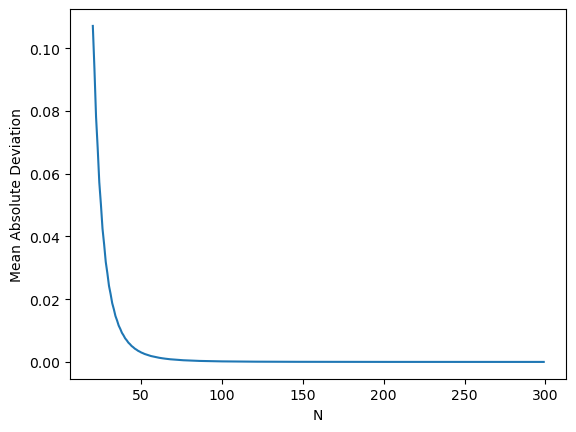

In [8]:
n=3
k=3

sstart = time.time()

RangeStart=20
RangeEnd=300
evals= chebyshev(RangeStart-1)[0]
evals5_record=np.sort(evals)[0:5]
RdiffL=[]
#AdiffL=[]

for myN in range(RangeStart,RangeEnd):

    evals= chebyshev(myN)[0]
    evals5=np.sort(evals)[0:5]
    Rdiff=0  #relative difference
    #Adiff=0  #absolute difference
    for i in range(5):
        Rdiff+=abs(evals5[i]-evals5_record[i])
        #Adiff+=abs(evals5[i]-analysis[i])
    Rdiff=Rdiff/5
    #Adiff=Adiff/5
    RdiffL.append(Rdiff)
    #AdiffL.append(Adiff)
    evals5_record=evals5
    
'''
print("The Relative Difference is:")
print(RdiffL)
print("The Absolute Difference is:")
print(AdiffL)
'''

                               
plt.plot(range(RangeStart,RangeEnd),RdiffL)
plt.xlabel("N")
plt.ylabel("Mean Absolute Deviation")



eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)

Text(0, 0.5, 'Mean Absolute Deviation^(-1/4)')

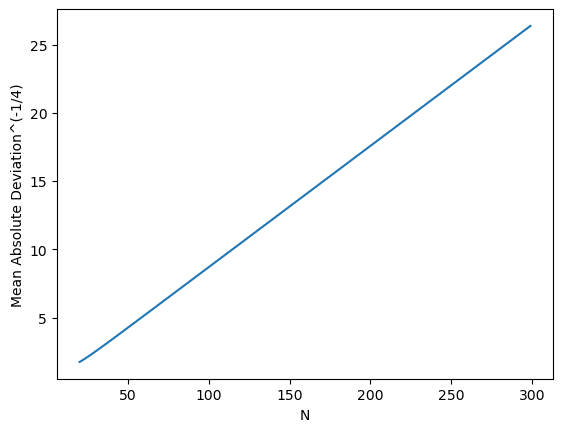

In [31]:
RdiffInv=[]
for i in RdiffL:
    RdiffInv.append(1/i**(1/4))
plt.plot(range(RangeStart,RangeEnd),RdiffInv)
plt.xlabel("N")
plt.ylabel("Mean Absolute Deviation^(-1/4)")


### Therefore, the Relative Difference is decreasing in the order of 1/N^4 


# Difference Test - Root mean square


The total time is :
461.1388039588928


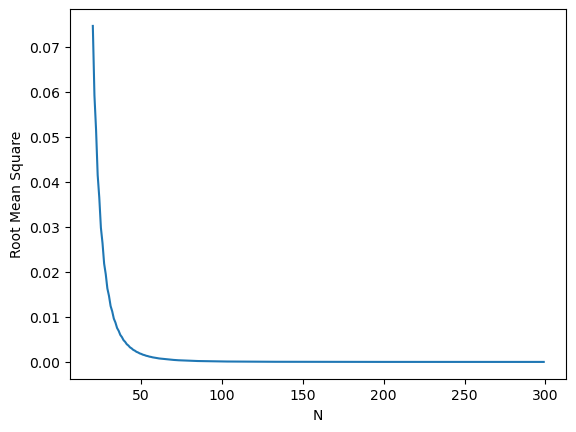

In [38]:

sstart = time.time()

RangeStart=20
RangeEnd=300
evals= chebyshev(RangeStart-1)[0]
evals5_record=np.sort(evals)[0:4]
RMSdiffL=[]
#AdiffL=[]

for myN in range(RangeStart,RangeEnd):

    evals= chebyshev(myN)[0]
    evals5=np.sort(evals)[0:4]
    Rdiff=0  #relative difference
    #Adiff=0  #absolute difference
    for i in range(4):
        Rdiff+=(evals5[i]-evals5_record[i])**2
        #Adiff+=abs(evals5[i]-analysis[i])
    Rdiff=Rdiff**(1/2)/2
    #Adiff=Adiff/5
    RMSdiffL.append(Rdiff)
    #AdiffL.append(Adiff)
    evals5_record=evals5
    


                               
plt.plot(range(RangeStart,RangeEnd),RMSdiffL)
plt.xlabel("N")
plt.ylabel("Root Mean Square")


#ax2.plot(range(RangeStart,RangeEnd),AdiffL)
#ax2.set_title("Absolute Difference vs N")





eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)

Text(0, 0.5, 'Root Mean Square^(-1/4)')

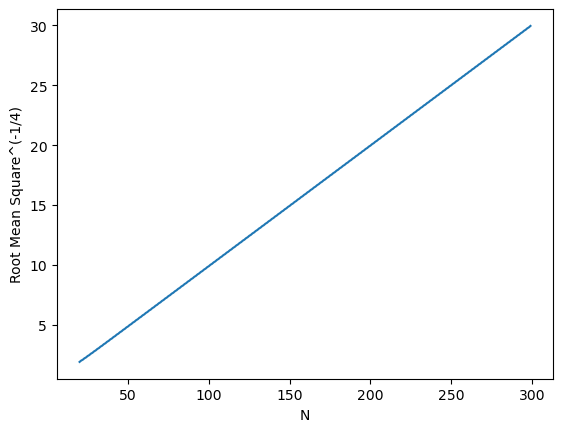

In [40]:
RdiffInv=[]
for i in RMSdiffL:
    RdiffInv.append(1/i**(1/4))
plt.plot(range(RangeStart,RangeEnd),RdiffInv)
plt.xlabel("N")
plt.ylabel("Root Mean Square^(-1/4)")


###  The Root Mean Square is also decreasing in the order of 1/N^4 


The total time is :
326.74520897865295


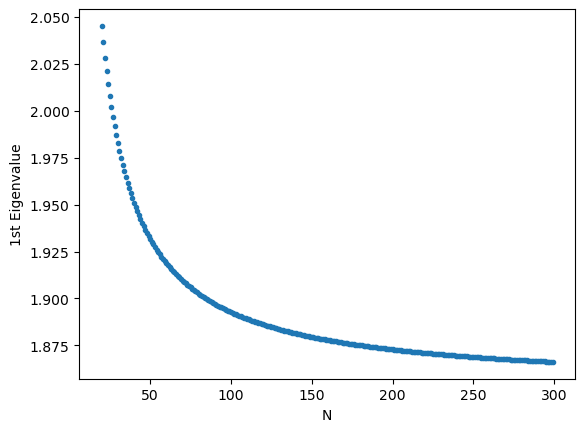

In [4]:
n=0
k=0

sstart = time.time()

RangeStart=20
RangeEnd=300
feval=[]

for myN in range(RangeStart,RangeEnd):
    feval.append(np.sort(chebyshev(myN)[0])[1])


    
plt.plot(range(RangeStart,RangeEnd),feval,'.')
plt.xlabel("N")
plt.ylabel("1st Eigenvalue")



eend = time.time()
totaltime=eend-sstart
print("The total time is :")
print(totaltime)



### The cells below are just for testing purpose, not related to our work.

In [87]:
for i in range(number_of_evals*(nRange+1)*(kRange+1)):
    print(i)

0
1
2
3
4
5
6
7


In [75]:


a = np.array([[1, 1], [2, 24], [3, 3],[24,24]])
max_xy = np.where(a == a.max() )
max_xy

(array([1, 3, 3], dtype=int64), array([1, 0, 1], dtype=int64))

In [98]:
b=[1]
a=[]
a.append(b)
print(a)
b=2
print(a)
a.append(b)
print(a)

[[1]]
[[1]]
[[1], 2]


In [34]:
df1 = pd.DataFrame([['a', 'b'], ['c', 'd']],
                   index=['row 1', 'row 2'],
                   columns=['col 1', 'col 2'])
df1.to_excel("output.xlsx") 

In [22]:
d=list(range(120))
print(d)
a=len(d)
print(a)
b=a//50
c=a%50
print(b,c)
for i in range(b):
    print(d[50*i:50*i+50])

print(d[-c:-1]+[d[-1]])

[0, 1, 2]

In [ ]:
[3*x for x in [111, 222, 333]]